# Hierarchical Clustering — Theory to Implementation

This notebook is the **hands-on companion** to `Hierarchical_Clustering_Notes.md`.
It walks through every concept from the notes, in order, with runnable code:

1. Setup
2. Manual 6-point walkthrough (agglomerative merging intuition)
3. Distance metrics: Euclidean vs Manhattan vs Cosine
4. Building & reading a Dendrogram
5. The "longest vertical line" trick to auto-pick `k`
6. Linkage methods comparison (single, complete, average, ward)
7. Full real-world pipeline: Iris dataset (scaling + PCA + dendrogram + AgglomerativeClustering)
8. K-Means vs Hierarchical Clustering — side-by-side demo
9. Key takeaways

> Run the cells top to bottom. Everything here uses only `numpy`, `pandas`, `matplotlib`, `scipy`, and `scikit-learn`.


## 1. Setup — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, confusion_matrix

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Manual 6-Point Walkthrough (Agglomerative Merging Intuition)

Just like in the notes: we start with 6 points (P1...P6), each its own cluster, and watch how
agglomerative clustering merges the nearest ones step by step, exactly like a family tree growing.

**Real-life analogy:** think of 6 coworkers who don't know each other yet at a new office.
The two who sit closest / talk most often team up first; small teams then merge into bigger
teams, until eventually the whole office is "one cluster" (the company).

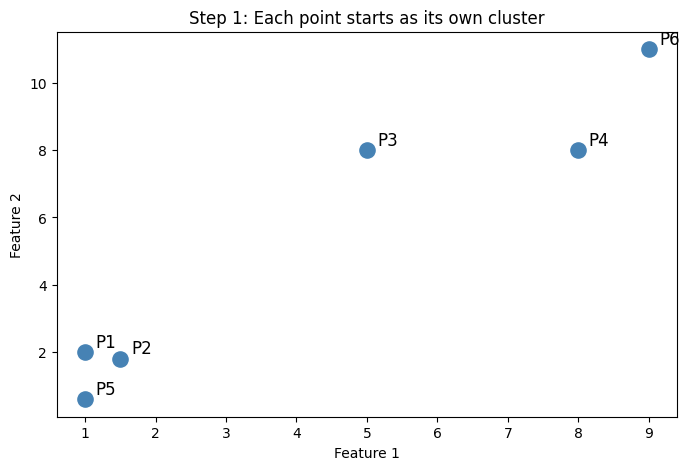

In [2]:
# 6 toy points, similar spirit to the P1...P6 example in the notes
points = np.array([
    [1, 2],   # P1
    [1.5, 1.8], # P2
    [5, 8],   # P3
    [8, 8],   # P4
    [1, 0.6], # P5
    [9, 11],  # P6
])
labels_p = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

plt.scatter(points[:, 0], points[:, 1], s=120, color='steelblue')
for i, lbl in enumerate(labels_p):
    plt.annotate(lbl, (points[i, 0] + 0.15, points[i, 1] + 0.15), fontsize=12)
plt.title('Step 1: Each point starts as its own cluster')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


In [3]:
# Step 2 & 3: Repeatedly merge nearest clusters (this is exactly what `linkage` computes)
Z = linkage(points, method='ward')

print("Merge history (each row = one merge step):")
print("[cluster_A_id, cluster_B_id, distance_at_merge, num_points_in_new_cluster]\n")
print(Z)


Merge history (each row = one merge step):
[cluster_A_id, cluster_B_id, distance_at_merge, num_points_in_new_cluster]

[[ 0.          1.          0.53851648  2.        ]
 [ 4.          6.          1.52861593  3.        ]
 [ 2.          3.          3.          2.        ]
 [ 5.          8.          4.50924975  3.        ]
 [ 7.          9.         16.86228533  6.        ]]


Every row above is one *merge event* — this table is the raw data behind a dendrogram. Let's actually draw the dendrogram now.

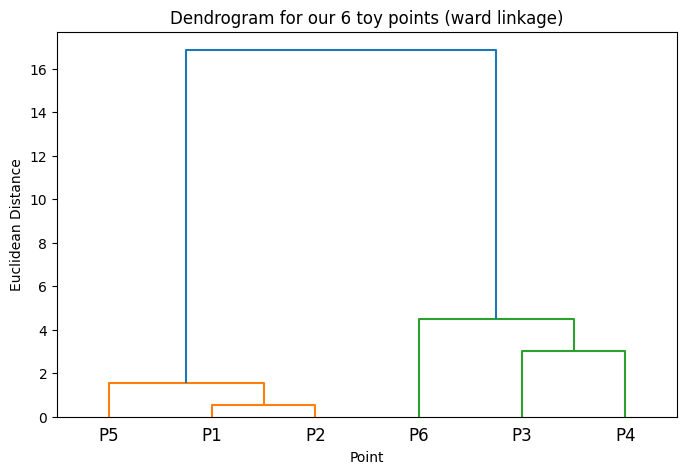

In [4]:
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels_p)
plt.title('Dendrogram for our 6 toy points (ward linkage)')
plt.xlabel('Point')
plt.ylabel('Euclidean Distance')
plt.show()


## 3. Distance Metrics: Euclidean vs Manhattan vs Cosine

Recap from the notes:
- **Euclidean distance** — straight-line ("as the crow flies") distance. Used by default in most clustering.
- **Manhattan distance** — sum of absolute differences ("city block" distance, like navigating grid streets).
- **Cosine similarity/distance** — measures the *angle* between two vectors, ignoring magnitude. This is what lets Hierarchical Clustering work on non-numeric-feeling data like movies, documents, etc. (as discussed in the notes).

In [5]:
from scipy.spatial.distance import euclidean, cityblock, cosine

a = np.array([2, 4, 4, 6])   # e.g., a "movie" represented as a genre-intensity vector
b = np.array([5, 5, 3, 8])

print(f"Euclidean distance : {euclidean(a, b):.3f}")
print(f"Manhattan distance : {cityblock(a, b):.3f}")
print(f"Cosine distance     : {cosine(a, b):.3f}  (0 = identical direction, 1 = orthogonal, 2 = opposite)")


Euclidean distance : 3.873
Manhattan distance : 7.000
Cosine distance     : 0.044  (0 = identical direction, 1 = orthogonal, 2 = opposite)


**Real-life example:** Two movies can have very different "intensity" (one is a blockbuster with huge feature values, one is a small indie film with modest values) but still be very *similar in genre proportions* — cosine distance captures that similarity even when Euclidean distance would say they're far apart.

## 4 & 5. Choosing `k`: Threshold Method + the "Longest Vertical Line" Trick

We'll generate a clearer synthetic dataset with 3 natural groups, build the dendrogram,
and programmatically find the best cut — mirroring what the notes describe visually.

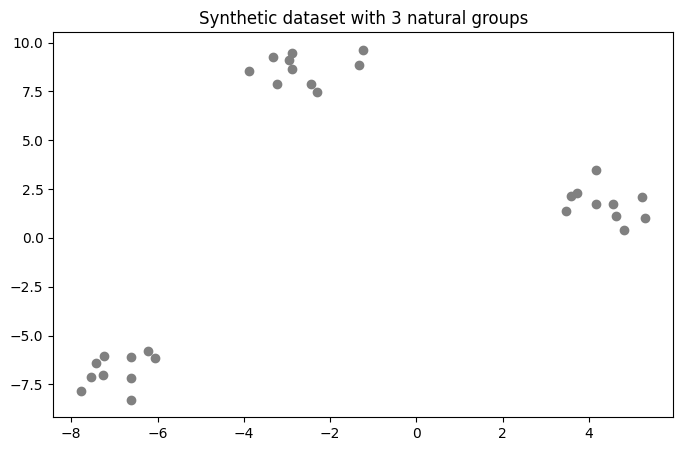

In [6]:
from sklearn.datasets import make_blobs

X_blobs, y_true = make_blobs(n_samples=30, centers=3, cluster_std=0.8, random_state=42)

plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c='gray')
plt.title('Synthetic dataset with 3 natural groups')
plt.show()


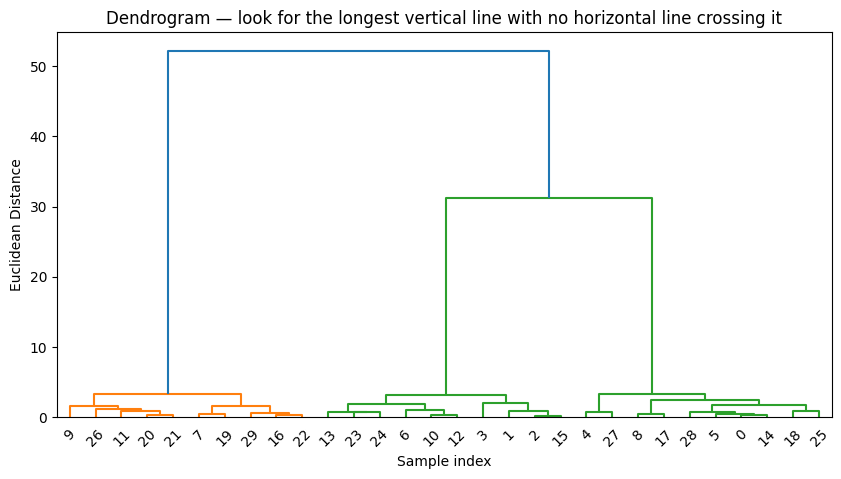

In [7]:
Z_blobs = linkage(X_blobs, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z_blobs)
plt.title('Dendrogram — look for the longest vertical line with no horizontal line crossing it')
plt.xlabel('Sample index')
plt.ylabel('Euclidean Distance')
plt.show()


In [8]:
# Programmatic version of the "longest vertical line" trick:
# The merge distances are in Z_blobs[:, 2]. The biggest GAP between consecutive
# merge distances tells us where the "longest uninterrupted vertical line" is.
merge_distances = Z_blobs[:, 2]
gaps = np.diff(merge_distances)
best_gap_index = np.argmax(gaps)

# Number of clusters = (number of merges remaining after the biggest gap) + 1
n_clusters_suggested = len(merge_distances) - best_gap_index
threshold = (merge_distances[best_gap_index] + merge_distances[best_gap_index + 1]) / 2

print(f"Suggested cut threshold : {threshold:.3f}")
print(f"Suggested number of clusters (k) : {n_clusters_suggested}")


Suggested cut threshold : 17.238
Suggested number of clusters (k) : 3


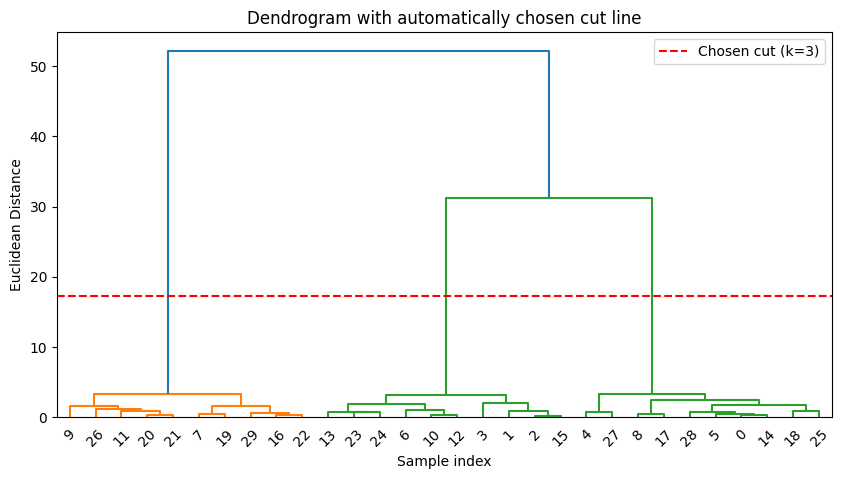

In [9]:
plt.figure(figsize=(10, 5))
dendrogram(Z_blobs)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Chosen cut (k={n_clusters_suggested})')
plt.title('Dendrogram with automatically chosen cut line')
plt.xlabel('Sample index')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.show()


## 6. Linkage Methods Comparison

Let's visually compare all four linkage methods from the notes on the same dataset:
`single`, `complete`, `average`, and `ward`.

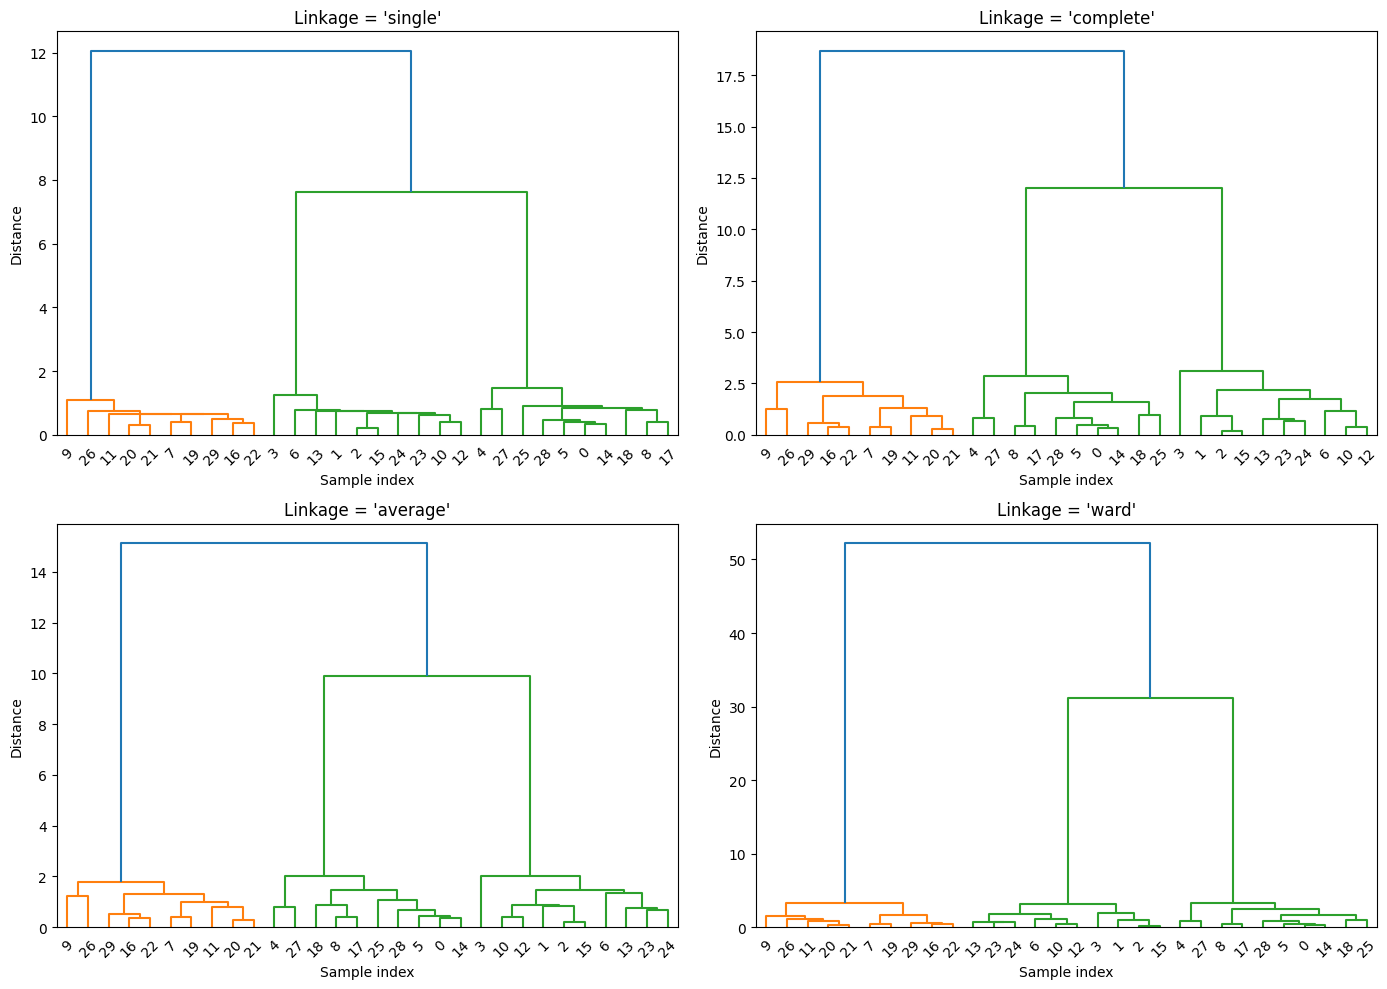

In [11]:
methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, method in zip(axes, methods):
    Z_method = linkage(X_blobs, method=method)
    dendrogram(Z_method, ax=ax)
    ax.set_title(f"Linkage = '{method}'")
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()


**Observation:** `single` linkage often produces long "chained" merges (sensitive to noise),
while `ward` tends to produce the most balanced, evenly-sized clusters — which is why `ward` is the
most popular default in real projects.

## 7. Full Real-World Pipeline — Iris Dataset

This reproduces the exact implementation walked through in the notes (Section 12):
Load data → Scale → PCA → Dendrogram → AgglomerativeClustering → Compare with real species labels.

In [12]:
# Step 1: Load the Iris dataset
iris = datasets.load_iris()
iris_data = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_data.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
# Step 2: Feature Scaling (Standardization) -- CRITICAL before any distance-based algorithm
scalar = StandardScaler()
X_scale = scalar.fit_transform(iris_data)
print("Scaled data shape:", X_scale.shape)


Scaled data shape: (150, 4)


In [14]:
# Step 3: Dimensionality reduction with PCA (4 features -> 2, purely for visualization)
pca = PCA(n_components=2)
pca_scaled_data = pca.fit_transform(X_scale)
print("Explained variance ratio of the 2 components:", pca.explained_variance_ratio_)


Explained variance ratio of the 2 components: [0.72962445 0.22850762]


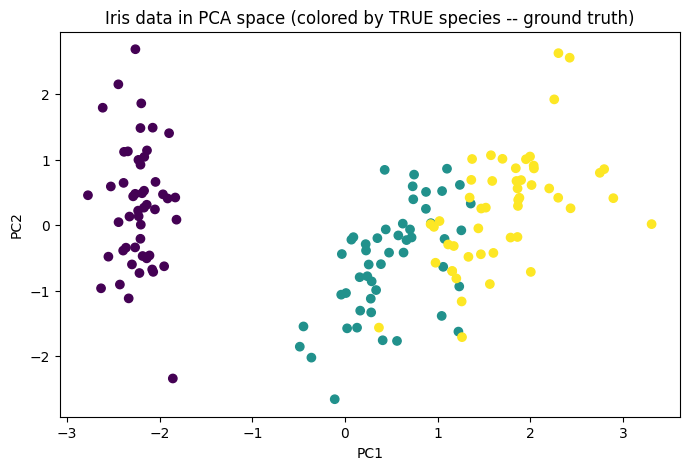

In [15]:
# Step 4: Sanity-check scatter plot, colored by REAL species (ground truth) -- for comparison only
plt.scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=iris.target, cmap='viridis')
plt.title('Iris data in PCA space (colored by TRUE species -- ground truth)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


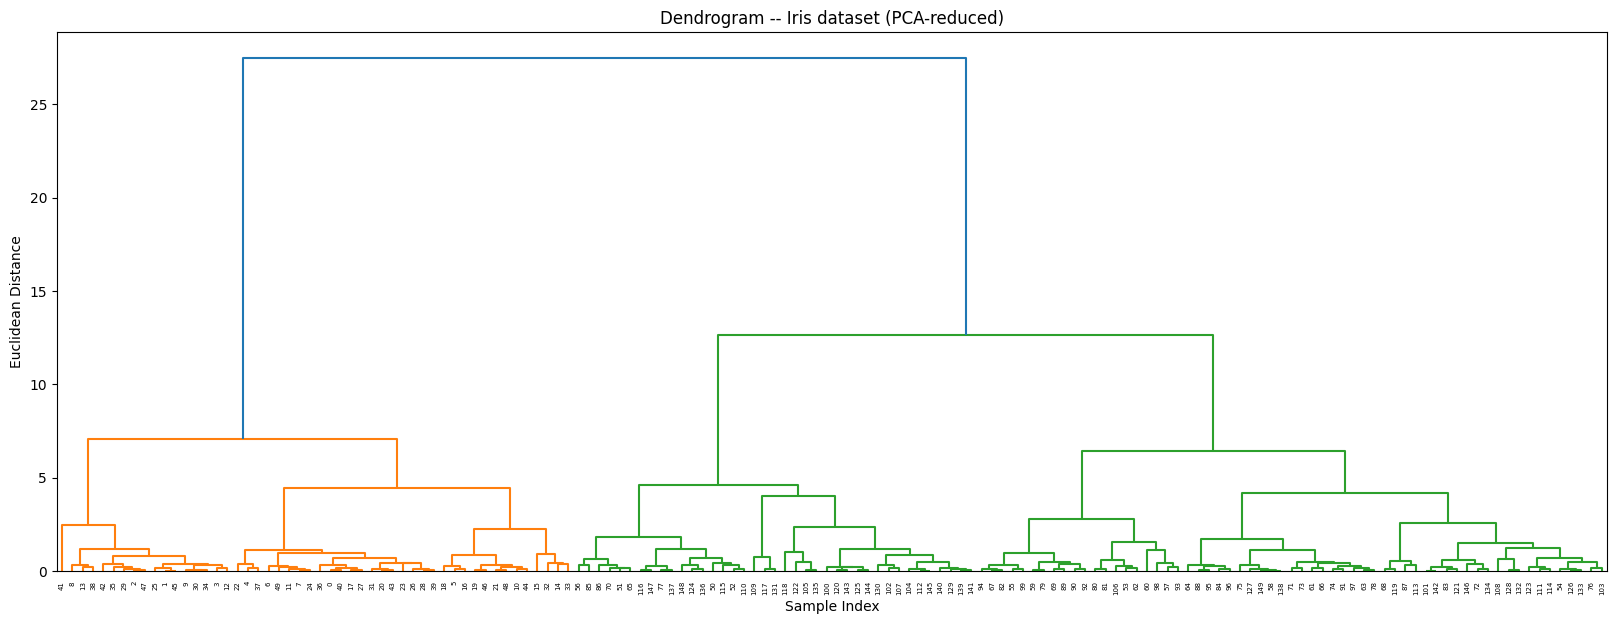

In [16]:
# Step 5: Construct the dendrogram (ward linkage, as in the notes)
plt.figure(figsize=(20, 7))
plt.title('Dendrogram -- Iris dataset (PCA-reduced)')
dend = dendrogram(linkage(pca_scaled_data, method='ward'))
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.show()


Applying the "longest vertical line" trick here suggests **k = 2** — even though we know there
are 3 species! This is because two species (versicolor & virginica) overlap heavily in feature space
and aren't cleanly separable, while the third (setosa) is very distinct. A great real-world lesson:
**unsupervised learning finds patterns in the data, not necessarily the labels humans assigned.**

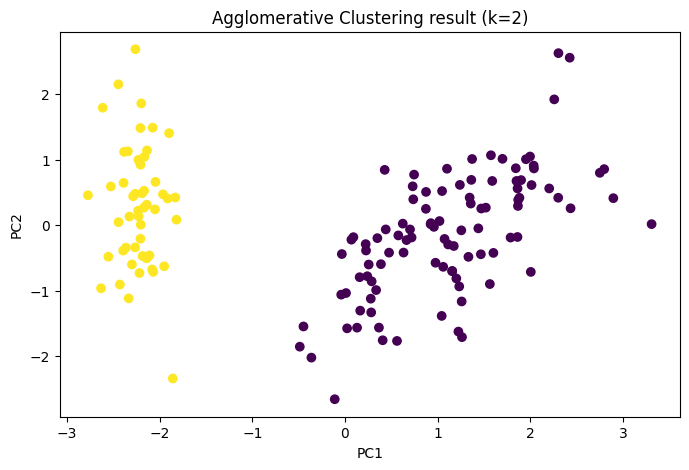

In [17]:
# Step 6: Apply Agglomerative Clustering with k=2
# NOTE: newer scikit-learn versions use `metric` instead of the deprecated `affinity` parameter.
cluster_k2 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
cluster_k2.fit(pca_scaled_data)

plt.scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=cluster_k2.labels_, cmap='viridis')
plt.title('Agglomerative Clustering result (k=2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


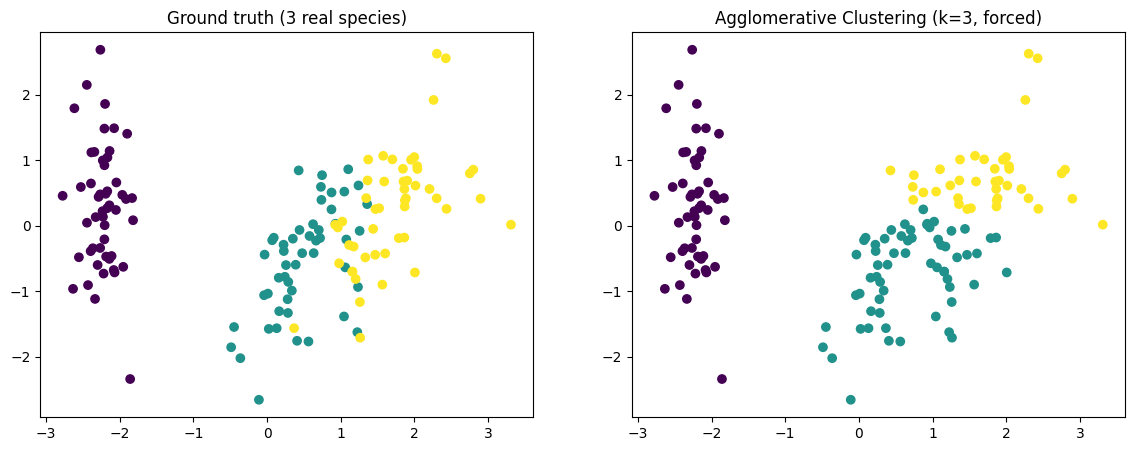

Confusion matrix (true species vs k=3 clusters):
[[50  0  0]
 [ 0 41  9]
 [ 0 20 30]]


In [18]:
# Bonus: what if we force k=3 to match the real number of species? Let's compare.
cluster_k3 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
cluster_k3.fit(pca_scaled_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=iris.target, cmap='viridis')
axes[0].set_title('Ground truth (3 real species)')
axes[1].scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=cluster_k3.labels_, cmap='viridis')
axes[1].set_title('Agglomerative Clustering (k=3, forced)')
plt.show()

print("Confusion matrix (true species vs k=3 clusters):")
print(confusion_matrix(iris.target, cluster_k3.labels_))


In [19]:
# Evaluate clustering quality with Silhouette Score (higher = better separated clusters)
sil_k2 = silhouette_score(pca_scaled_data, cluster_k2.labels_)
sil_k3 = silhouette_score(pca_scaled_data, cluster_k3.labels_)
print(f"Silhouette score (k=2): {sil_k2:.3f}")
print(f"Silhouette score (k=3): {sil_k3:.3f}")
print("\nA higher silhouette score generally means better-defined clusters --")
print("compare this with what the dendrogram suggested!")


Silhouette score (k=2): 0.615
Silhouette score (k=3): 0.511

A higher silhouette score generally means better-defined clusters --
compare this with what the dendrogram suggested!


## 8. K-Means vs Hierarchical Clustering — Side-by-Side Demo

Quick practical demo of the notes' comparison table: same data, both algorithms, same k.

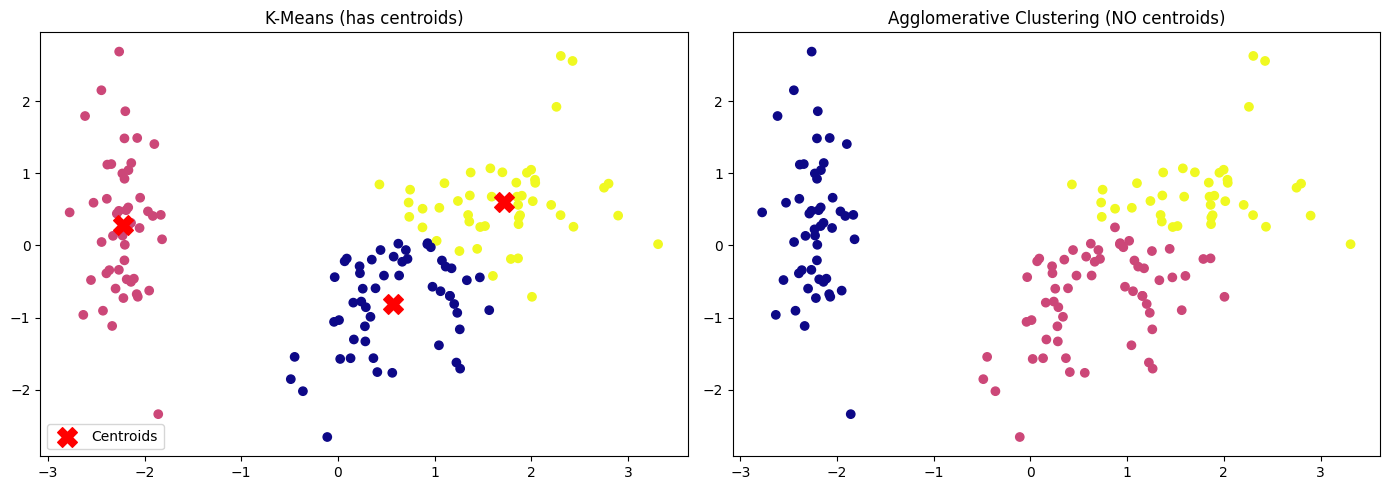

Notice K-Means plots red 'X' centroids -- Hierarchical Clustering has no such concept.


In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_scaled_data)

hier = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hier_labels = hier.fit_predict(pca_scaled_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=kmeans_labels, cmap='plasma')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='red', label='Centroids')
axes[0].set_title('K-Means (has centroids)')
axes[0].legend()

axes[1].scatter(pca_scaled_data[:, 0], pca_scaled_data[:, 1], c=hier_labels, cmap='plasma')
axes[1].set_title('Agglomerative Clustering (NO centroids)')

plt.tight_layout()
plt.show()

print("Notice K-Means plots red 'X' centroids -- Hierarchical Clustering has no such concept.")


## 9. Key Takeaways (Recap)

- Agglomerative clustering repeatedly merges the two nearest clusters until one giant cluster remains.
- A **dendrogram** visualizes the entire merge history; cutting it at the right height gives you `k`.
- The **longest vertical line with no horizontal crossing** is the best place to cut (we even automated it above using the biggest gap between merge distances).
- **Linkage method** (single/complete/average/ward) changes how "distance between clusters" is defined — `ward` is the most commonly used default.
- Hierarchical clustering works with **Euclidean, Manhattan, or Cosine** distance/similarity — making it flexible for numeric AND non-numeric-feeling data (e.g. movies, documents).
- **Scalability:** Hierarchical clustering struggles on huge datasets (dendrograms become unreadable); K-Means scales much better.
- Always **scale your features** before any distance-based clustering algorithm.

### Next
Head to the project notebooks for real-world, end-to-end use cases:
- `Project1_Mall_Customer_Segmentation.ipynb`
- `Project2_Iris_Clustering_Deep_Dive.ipynb`
- `Project3_Wholesale_Customers_Segmentation.ipynb`
- `Project4_Text_Clustering.ipynb`
